# Stop when you're done

Write a kernel that knows when its own sample has finished, then run one
trajectory on the CPU and a batch on the GPU with the same call.

**Time:** ~8 min · **Runs on:** CPU, GPU switch · **You need:**
[Arguments and shapes](02_arguments_and_shapes)

A *stepping* kernel advances one sample by one step and declares a
`Terminated` plane — a per-sample "done" flag. A sample already flagged
`terminated` going into a step keeps its outputs exactly where they
landed, so a batch of samples that finish at different times never
corrupts the ones still running.

In [1]:
import hawk
from hawk import Mutable, Param, Scalar, Terminated


@hawk.kernel
def oscillator(omega: Scalar, t_end: Scalar, dt: Param, terminated: Terminated,
               x: Mutable[Scalar], v: Mutable[Scalar], t: Mutable[Scalar]):
    x, v = x + dt * v, v - dt * omega * omega * x   # tuple: reads step-start x, v
    t = t + dt
    terminated = t >= t_end


oscillator


<Kernel oscillator slots=9>

## Tuple vs two lines

Reading `x`, `v` or `t` before writing them gives the value each held at
the **start** of this step. `x, v = x + dt*v, v - dt*omega*omega*x`
above is a tuple assignment: both expressions on the right read the
OLD `x` and `v` — the explicit Euler method. Two separate lines,
`x = x + dt*v` then `v = v - dt*omega*omega*x`, let the second line read
the NEW `x` the first just wrote — the symplectic (semi-implicit) Euler
method, which conserves an oscillator's energy far better over many
steps:

In [2]:
@hawk.kernel
def oscillator_sequential(omega: Scalar, t_end: Scalar, dt: Param,
                           terminated: Terminated, x: Mutable[Scalar],
                           v: Mutable[Scalar], t: Mutable[Scalar]):
    x = x + dt * v                        # old v
    v = v - dt * omega * omega * x        # NEW x, just written above
    t = t + dt
    terminated = t >= t_end


In [3]:
import eagle

energy = lambda r, omega: 0.5 * (float(r.v) ** 2 + omega ** 2 * float(r.x) ** 2)
for name, kernel in [("tuple (explicit Euler)", oscillator),
                      ("two lines (symplectic Euler)", oscillator_sequential)]:
    r = eagle.simulate(kernel, x=1.0, v=0.0, t=0.0, omega=2.0, t_end=20.0,
                        dt=1e-2, max_steps=100_000)
    msg = f"{name}: energy at t={float(r.t):.0f} is {energy(r, 2.0):.3f}"
    print(msg, "(started at 2.000)")


tuple (explicit Euler): energy at t=20 is 4.450 (started at 2.000)


two lines (symplectic Euler): energy at t=20 is 1.980 (started at 2.000)


Same arithmetic, same effort to type; which integrator you get depends
only on whether the comma is there. (`eagle.simulate` itself is
introduced properly next — this cell only needed it to run the two
kernels forward.)

## One trajectory, by name

`eagle.simulate(model, max_steps=..., **kwargs)` takes the kernel and
every plane it reads or writes, by name — no separate `state=`/`params=`
grouping, and no `terminated` to pass, since the kernel itself sets that
— and runs it until every sample finishes or `max_steps` is reached: the
loop above never appears in your code. Plain floats in means one
trajectory, on the CPU:


In [4]:
one = eagle.simulate(oscillator, x=1.0, v=0.0, t=0.0, omega=2.0, t_end=1.0,
                     dt=1e-3, max_steps=10_000)
print(one.status, "t:", float(one.t), "x:", float(one.x), "v:", float(one.v))


finished t: 1.0000000000000007 x: -0.41697753175791447 v: -1.8222378995667639


(`one.steps` would print 1024, not 1000: `eagle.simulate` launches in
fixed-size batches, so the launch count can run a little past what the
physics actually needed once every sample has landed. `t` is the number
that answers "did it reach `t_end`".)

## The same call, a whole batch

Hand it `xp` arrays instead of floats — one value per sample — and it runs
the identical kernel over every one of them, on the device the arrays live
on. This notebook runs a GPU batch when one is visible, and a smaller CPU
batch otherwise (every tutorial here runs on CPU).

In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "_shared"))
from nb_helpers import DEVICE, batch_size, plot_style, xp
plot_style()

In [6]:
import numpy as np

n = batch_size(gpu=1_000_000, cpu=100_000)   # same kernel either way
rng = np.random.default_rng(1)
omega_b = rng.uniform(1.0, 3.0, n)
omega_b[0] = 2.0   # sample 0 matches the single trajectory above

batch = eagle.simulate(oscillator, x=xp.ones(n), v=xp.zeros(n), t=xp.zeros(n),
                       omega=xp.asarray(omega_b), t_end=xp.full(n, 1.0), dt=1e-3,
                       max_steps=10_000)
print(f"{n} samples on {DEVICE}: finished={int(batch.finished.sum())}/{batch.n}, "
     f"wall_s={batch.wall_s:.3f}")
print("trajectory 0 agrees with the single run above:",
      abs(float(batch.x[0]) - float(one.x)) < 1e-6)


100000 samples on cpu: finished=100000/100000, wall_s=0.024
trajectory 0 agrees with the single run above: True


## Five samples, five stopping times

Each sample's `t_end` is its own value, so five samples started together
stop on five different steps. Calling `eagle.simulate` with a growing
`max_steps` and recording the state each time traces out every sample's
`x(t)` up to where it lands — a cheap way to see the trajectory, not how
you would do this at scale (a single `max_steps` call, as above, is the
right one for that).

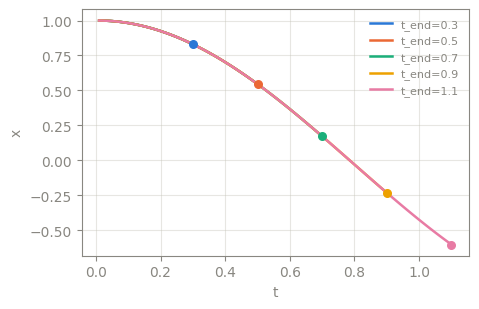

In [7]:
import matplotlib.pyplot as plt

n5 = 5
t_ends = np.array([0.3, 0.5, 0.7, 0.9, 1.1])
xs, ts = [], []
for k in range(1, 200):
    r = eagle.simulate(oscillator, x=np.ones(n5), v=np.zeros(n5), t=np.zeros(n5),
                       omega=np.full(n5, 2.0), t_end=t_ends, dt=1e-2, max_steps=k)
    xs.append(np.asarray(r.x).copy())
    ts.append(np.asarray(r.t).copy())
    if r.done:
        break
xs, ts = np.array(xs), np.array(ts)

fig, ax = plt.subplots(figsize=(5, 3.2))
colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
for i in range(n5):
    ax.plot(ts[:, i], xs[:, i], color=colors[i], lw=1.8, label=f"t_end={t_ends[i]}")
    ax.scatter([ts[-1, i]], [xs[-1, i]], color=colors[i], s=30, zorder=3)
ax.set_xlabel("t"); ax.set_ylabel("x"); ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.4)
plt.show()


## What just happened

- `Terminated`, plus reading a `Mutable` before writing it, declare a
  kernel that advances its own sample and knows when that sample is
  done; a finished sample's outputs stay frozen at the value they
  landed on.
- Tuple assignment reads every old value on one line (explicit Euler);
  two sequential lines let a later one read an earlier line's new value
  (symplectic Euler) — same cost, different integrator.
- `eagle.simulate(kernel, max_steps=..., **kwargs)` loops the kernel
  until every sample finishes, for one sample (plain floats) or a whole
  batch (`xp` arrays) with the exact same call — every plane the kernel
  reads or writes, passed by name, with no `terminated` to supply.

## Try this

Lower `max_steps` in the batch cell to something smaller than the loop
needs (say `200`) and check `batch.status` — it reports `"max_steps"`
instead of `"finished"`.

## Next

[Gradients, backward](04_gradients_backward) — get d(output)/d(input) for
every sample of a kernel like this one.
